<a href="https://colab.research.google.com/github/vennachedushivani14-hub/house-price-prediction/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()  # Upload 'house_data.csv'

Saving Housing.csv to Housing (1).csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
# Check all column names
print("Columns in dataset:", df.columns)

Columns in dataset: Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [7]:
# Count missing values in each column
print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [8]:
# Convert Yes/No columns to 0/1
yes_no_cols = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']
for col in yes_no_cols:
    df[col] = df[col].map({'yes':1,'no':0})

# Convert furnishingstatus to numeric: 'furnished','semi-furnished','unfurnished'
df['furnishingstatus'] = df['furnishingstatus'].map({
    'unfurnished': 0,
    'semi-furnished': 1,
    'furnished': 2
})

In [9]:
# Check first 5 rows
print(df.head())

# Check data types
print(df.info())

      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus  
0                 2  
1                 2  
2                 1  
3                 2  
4                 2  
<class 'pandas.core.frame.

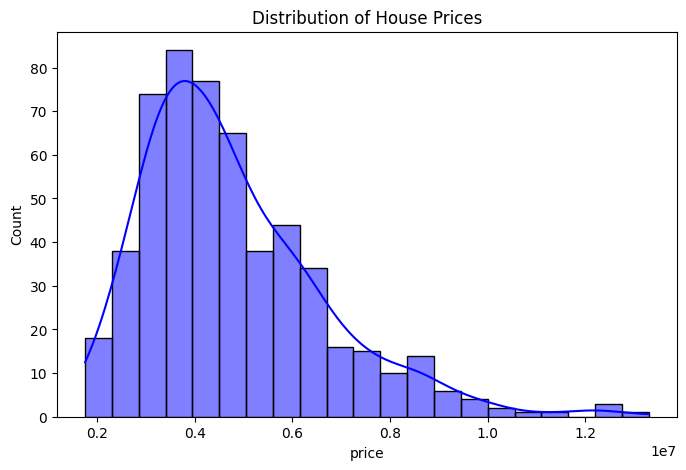

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Check distribution of target variable (price)
plt.figure(figsize=(8,5))
sns.histplot(df['price'], kde=True, color='blue')
plt.title("Distribution of House Prices")
plt.show()

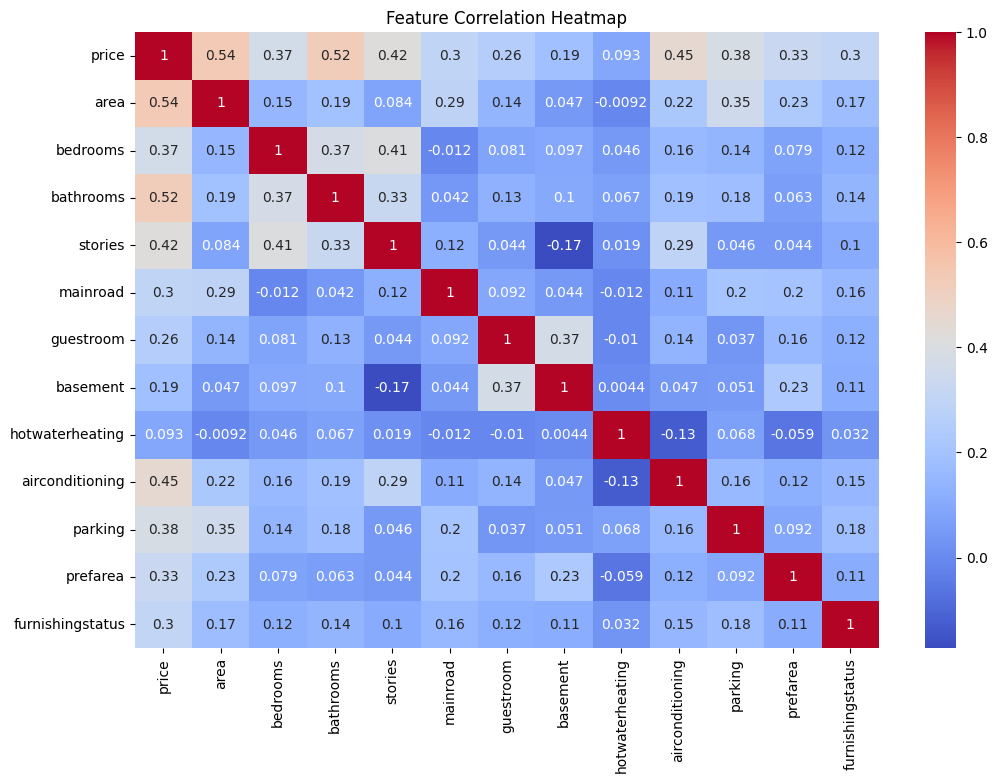

In [11]:
# 2️⃣ Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [12]:
# Target variable
y = df['price']

# Features
X = df.drop('price', axis=1)

# Check features
X.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,1,0,0,0,1,2,1,2
1,8960,4,4,4,1,0,0,0,1,3,0,2
2,9960,3,2,2,1,0,1,0,0,2,1,1
3,7500,4,2,2,1,0,1,0,1,3,1,2
4,7420,4,1,2,1,1,1,0,1,2,0,2


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 436
Testing samples: 109


In [14]:
from sklearn.linear_model import LinearRegression

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

LinearRegression()

In [15]:
# Predict on test set
y_pred = model.predict(X_test)

# Check first 10 predictions vs actual
for actual, pred in list(zip(y_test[:10], y_pred[:10])):
    print(f"Actual: {actual}, Predicted: {pred:.2f}")

Actual: 4060000, Predicted: 5203691.71
Actual: 6650000, Predicted: 7257004.02
Actual: 3710000, Predicted: 3062828.60
Actual: 6440000, Predicted: 4559591.65
Actual: 2800000, Predicted: 3332932.31
Actual: 4900000, Predicted: 3563080.68
Actual: 5250000, Predicted: 5645466.31
Actual: 4543000, Predicted: 6413979.67
Actual: 2450000, Predicted: 2755831.55
Actual: 3353000, Predicted: 2668938.66


In [16]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R² Score: {r2:.2f}")

Mean Absolute Error (MAE): 979679.69
R² Score: 0.65


In [17]:
import pickle

# Save model to file
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

# Optional: download file to your computer
from google.colab import files
files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
# Create app.py file
%%writefile app.py

import streamlit as st
import pickle
import numpy as np

# Load trained model
model = pickle.load(open("model.pkl", "rb"))

st.title("🏠 House Price Prediction App")

st.markdown("Enter the details of the house to predict the price.")

# Input fields
area = st.number_input("Area (in sq. ft)", min_value=100, max_value=10000, value=1200)
bedrooms = st.number_input("Bedrooms", min_value=1, max_value=10, value=3)
bathrooms = st.number_input("Bathrooms", min_value=1, max_value=5, value=2)
stories = st.number_input("Stories", min_value=1, max_value=5, value=1)
mainroad = st.selectbox("Main Road?", ["Yes","No"])
guestroom = st.selectbox("Guest Room?", ["Yes","No"])
basement = st.selectbox("Basement?", ["Yes","No"])
hotwaterheating = st.selectbox("Hot Water Heating?", ["Yes","No"])
airconditioning = st.selectbox("Air Conditioning?", ["Yes","No"])
parking = st.number_input("Parking Spaces", min_value=0, max_value=5, value=1)
prefarea = st.selectbox("Preferred Area?", ["Yes","No"])
furnishingstatus = st.selectbox("Furnishing Status", ["Unfurnished","Semi-furnished","Furnished"])

# Map categorical to numeric
yes_no_map = {"Yes":1,"No":0}
furnish_map = {"Unfurnished":0,"Semi-furnished":1,"Furnished":2}

mainroad = yes_no_map[mainroad]
guestroom = yes_no_map[guestroom]
basement = yes_no_map[basement]
hotwaterheating = yes_no_map[hotwaterheating]
airconditioning = yes_no_map[airconditioning]
prefarea = yes_no_map[prefarea]
furnishingstatus = furnish_map[furnishingstatus]

# Predict button
if st.button("Predict Price"):
    features = np.array([[area, bedrooms, bathrooms, stories, mainroad, guestroom,
                          basement, hotwaterheating, airconditioning, parking,
                          prefarea, furnishingstatus]])
    prediction = model.predict(features)
    st.success(f"🏡 Estimated Price: ${prediction[0]:,.2f}")

Writing app.py


In [19]:
from google.colab import files
files.download("app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
!pip install streamlit
!pip install pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 97.4 MB/s eta 0:00:00
